# Fig. 2 — uncoupled residues vs concerted switching across conformational timescales

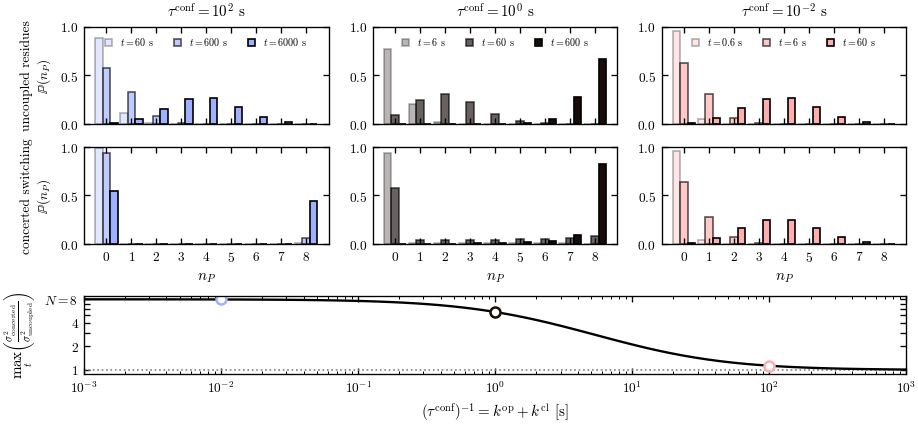

In [1]:
# ------------------------------------------------------------------
# concerted switching vs uncoupled residues:
#   scan k_op, k_cl for a fixed N and k_int, show how the uptake
#   envelope shape and the peak variance ratio depend on the switch
#   timescale.  Copy into a notebook cell; tweak the parameters at
#   the top.
# ------------------------------------------------------------------
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
from hdx_env import (
    UncoupledResidues, ConcertedSwitching, FullMarkov,
    averagine_composition, natural_envelope, mass_envelope,
    COLORS, LABELS,
)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Fixed peptide: k_int = 1 for every residue
# ---------------------------------------------------------------------------
N       = 8
P       = tuple(range(N))
k_int   = np.ones(N)
kk      = np.arange(N + 1)
t       = np.logspace(-4, 6, 401)
t_snaps = np.array([10, 100, 1000])

# ---------------------------------------------------------------------------
# Parameters: r1 = k_op/k_cl  fixed,  τ_conf = k_op + k_cl  scanned
# ---------------------------------------------------------------------------
r1         = 1.0 / 99.0                           # k_cl/k_op = 99
tau_values = np.array([1e-4, 1e-2, 1.0]) * (1.0 + 1.0/r1)
tau_scan   = np.logspace(np.log10(tau_values.min()) - 1.5,
                         np.log10(tau_values.max()) + 1.5, 80)

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def _centre_var(ud):
    m1 = (ud * kk).sum(axis=1)
    return m1, (ud * kk**2).sum(axis=1) - m1**2

def build_regimes(r1, tau):
    k_op = tau * r1 / (1.0 + r1)
    k_cl = tau       / (1.0 + r1)
    ind  = H.UncoupledResidues(np.full(N, k_op), np.full(N, k_cl), k_int)
    conc = H.ConcertedSwitching(k_op, k_cl, k_int)
    return ind, conc, k_op, k_cl

# ---------------------------------------------------------------------------
# Figure layout: 3 rows × len(tau_values) cols  (envelopes + peak-ratio)
# ---------------------------------------------------------------------------
nc  = len(tau_values)
fig = plt.figure(figsize=(2.4 * nc + 0.5, 3.6), constrained_layout=True)
gs  = fig.add_gridspec(3, nc,
                       height_ratios=[1.0, 1.0, 0.8])

ax_env = [[fig.add_subplot(gs[0, j]) for j in range(nc)],
          [fig.add_subplot(gs[1, j]) for j in range(nc)]]
for ax in ax_env[0]:
    plt.setp(ax.get_xticklabels(), visible=False)
ax_peak = fig.add_subplot(gs[2, :])      # peak-ratio sweep underneath

# ---------------------------------------------------------------------------
# Loop over showcase τ values: envelopes + peak-ratio markers
# ---------------------------------------------------------------------------


cmap = plt.get_cmap('berlin')
tau_colors  = [cmap(ti / max(nc - 1, 1)) for ti in range(nc)]
peak_ratios = []
for ti, tau in enumerate(tau_values):
    color       = tau_colors[ti]
    ind, conc, k_op, k_cl = build_regimes(r1, tau)

    # variance trajectories (used only for the peak ratio marker)
    _, v_i = _centre_var(ind .uptake_distribution(P, t))
    _, v_c = _centre_var(conc.uptake_distribution(P, t))

    # peak ratio marker
    mask = v_i > 1e-3 * v_i.max()
    peak_ratios.append(
        np.nanmax(np.where(mask, v_c / np.maximum(v_i, 1e-15), np.nan)))

    # envelopes at snapshot times
    ud_i_snap = ind .uptake_distribution(P, t_snaps/np.sqrt(tau)*6/10)
    ud_c_snap = conc.uptake_distribution(P, t_snaps/np.sqrt(tau)*6/10)
    width     = 0.9 / len(t_snaps)
    for si, tsnap in enumerate(t_snaps):
        off   = (si - (len(t_snaps) - 1) / 2) * width
        alpha = 0.3 + 0.7 * si / max(len(t_snaps) - 1, 1)
        ax_env[0][ti].bar(kk + off , ud_i_snap[si], width=width,
                          color=color, alpha=alpha,
                          label=rf'$t={tsnap/np.sqrt(tau)*6/10:g}$ s',
                          edgecolor='k', linewidth=1)
        ax_env[1][ti].bar(kk + off, ud_c_snap[si], width=width,
                          color=color, alpha=alpha,
                          label=rf'$t={tsnap/np.sqrt(tau)*6/10:g}$ s',
                          edgecolor='k', linewidth=1)
    for row in range(2):
        ax_env[row][ti].set_xticks(kk)
        ax_env[row][ti].set_ylim(0, 1.0)
        if ti == 0:
            ax_env[row][ti].set_ylabel(
                ['uncoupled residues', 'concerted switching'][row] + '\n' + r'$\mathbb{P}(n_P)$', fontsize=8)

    ax_env[1][ti].set_xlabel(r'$n_P$')
    exponent = int(round(np.log10(tau)))
    ax_env[0][ti].set_title(rf'$\tau^{{\rm conf}}= 10^{{{-exponent}}}$ s', fontsize=9)

peak_ratios = np.array(peak_ratios)

ax_env[0][0].legend(loc='upper center', fontsize=6, ncol=tsnap, handlelength=0.7, frameon=False)
ax_env[0][1].legend(loc='upper center', fontsize=6, ncol=tsnap, handlelength=0.7, frameon=False)
ax_env[0][2].legend(loc='upper center', fontsize=6, ncol=tsnap, handlelength=0.7, frameon=False)


# ---------------------------------------------------------------------------
# Peak-ratio sweep at finer resolution
# ---------------------------------------------------------------------------
R_scan = []
for tau in tau_scan:
    ind, conc, *_ = build_regimes(r1, tau)
    _, v_i = _centre_var(ind .uptake_distribution(P, t))
    _, v_c = _centre_var(conc.uptake_distribution(P, t))
    mask   = v_i > 1e-3 * v_i.max()
    ratio  = np.where(mask, v_c / np.maximum(v_i, 1e-15), np.nan)
    R_scan.append(np.nanmax(ratio))
R_scan = np.array(R_scan)

ax_peak.axhline(1.0, color='grey', ls=':', lw=1.0)
ax_peak.loglog(tau_scan, R_scan, '-', color='k', lw=1.4)
ax_peak.set_xlim(10**-3,10**3)
for tau_i, pr_i, col in zip(tau_values, peak_ratios, tau_colors):
    ax_peak.loglog(tau_i, pr_i, 'o', color=col,
                   ms=6, mfc='white', mew=1.5)
ax_peak.set_xlabel(r'$(\tau^{\rm conf})^{-1}=k^{\rm op}+k^{\rm cl}$ [s]', fontsize=9)
ax_peak.set_ylabel(r'$\max_t \left(\frac{\sigma^2_{\rm concerted}}{\sigma^2_{\rm uncoupled}} \right)$', fontsize=9)
ax_peak.set_yticks([1,2,3,4,5,6,7,8], labels=[1,2,'',4,'','','',r'$N=8$'])
#ax_peak.set_title(rf'$r_1=k_{{\rm op}}/k_{{\rm cl}}={r1:g}$, $N={N}$', fontsize=9)

fig.savefig(os.path.join(PLOTS_DIR, 'fig_concerted_variance_tconf.pdf'))
plt.show()

## Pair survival functionals

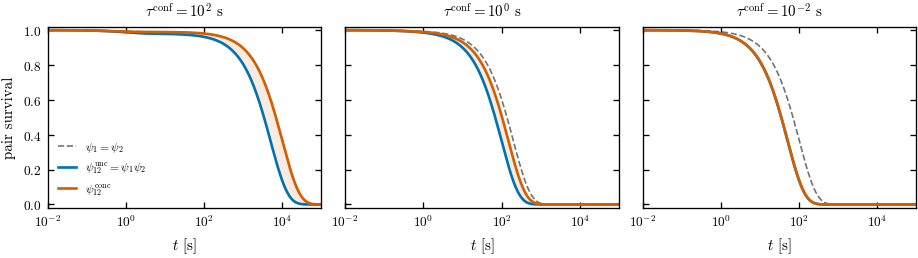

In [2]:
# ---------------------------------------------------------------------------
# Pair survival ψ_{12}(t) for the three showcase τ_conf values.
# Blue  : uncoupled residues  (ψ_{12} = ψ_1 ψ_2 = ψ_1^2)
# Orange: concerted switching (ψ_{12} = LL-survival with k_int = 2)
# Grey  : the common single-site survival ψ_1 = ψ_2 (same in both regimes)
# ---------------------------------------------------------------------------
col_unc  = COLORS['uncoupled']     # blue
col_conc = COLORS['concerted']     # orange-vermillion
col_ref  = '0.45'                  # grey for ψ_1

fig_ps, axes_ps = plt.subplots(1, len(tau_values),
                                figsize=(2.4 * len(tau_values) + 0.5, 2.2),
                                sharey=True, constrained_layout=True)

t_ps = np.logspace(-2, 5, 600)     # time grid (s)

for ti, tau in enumerate(tau_values):
    ax = axes_ps[ti]
    ind, conc, k_op, k_cl = build_regimes(r1, tau)

    psi_1   = ind.psi_i(0, t_ps)                  # single-site (same in both regimes)
    psi12_u = ind.psi_X((0, 1), t_ps)             # = ψ_1^2 for uncoupled
    psi12_c = conc.psi_X((0, 1), t_ps)            # LL survival with k_int=2

    ax.semilogx(t_ps, psi_1,   color=col_ref,  lw=1.0, ls='--',
                label=r'$\psi_1=\psi_2$')
    ax.semilogx(t_ps, psi12_u, color=col_unc,  lw=1.6,
                label=r'$\psi_{12}^{\rm unc}=\psi_1\psi_2$')
    ax.semilogx(t_ps, psi12_c, color=col_conc, lw=1.6,
                label=r'$\psi_{12}^{\rm conc}$')

    # shaded region: the gap between the factorised and concerted pair survivals
    ax.fill_between(t_ps, psi12_u, psi12_c,
                    where=(psi12_c >= psi12_u),
                    color=col_conc, alpha=0.12, lw=0)

    ax.set_xlim(t_ps[0], t_ps[-1])
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(r'$t$ [s]')
    exponent = int(round(np.log10(tau)))
    ax.set_title(rf'$\tau^{{\rm conf}}=10^{{{-exponent}}}$ s', fontsize=9)
    if ti == 0:
        ax.set_ylabel(r'pair survival')
        ax.legend(loc='lower left', fontsize=7, handlelength=1.5,
                   frameon=False)

fig_ps.savefig(os.path.join(PLOTS_DIR, 'fig_pair_survival_tconf.pdf'))
plt.show()

## Figure

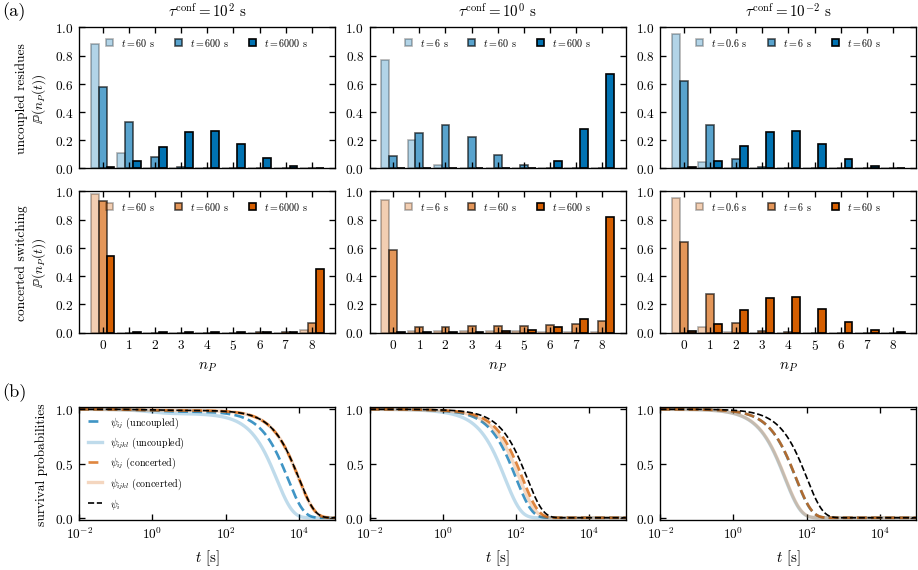

In [3]:
# ---------------------------------------------------------------------------
# 3 × 3 figure:
#   row 1 : uncoupled-residue envelopes at three τ_conf
#   row 2 : concerted-switching envelopes at three τ_conf
#   row 3 : pair survival functionals  ψ_1=ψ_2,  ψ_{12}^{conc},  ψ_1·ψ_2
# Colours: blue  = uncoupled,  orange = concerted,  grey = single-site reference.
# ---------------------------------------------------------------------------
col_unc   = COLORS['uncoupled']     # blue
col_conc  = COLORS['concerted']     # vermillion
col_ref   = '0.45'                  # single-site survival

nc = len(tau_values)
fig3, axes3 = plt.subplots(3, nc,
                            figsize=(2.4 * nc + 0.5, 4.8),
                            constrained_layout=True,
                            gridspec_kw={'height_ratios': [1.0, 1.0, .8]})

# panel-(row,col) colour mapping for the τ-snapshot envelopes,
# matching the existing figure's `berlin` palette
cmap_tau = plt.get_cmap('berlin')
tau_cols = [cmap_tau(ti / max(nc - 1, 1)) for ti in range(nc)]

t_ps = np.logspace(-2, 5, 600)

for ti, tau in enumerate(tau_values):
    ind, conc, k_op, k_cl = build_regimes(r1, tau)
    color_env = tau_cols[ti]

    # ----------------------------- envelopes ---------------------------------
    ud_i_snap = ind .uptake_distribution(P, t_snaps / np.sqrt(tau) * 6 / 10)
    ud_c_snap = conc.uptake_distribution(P, t_snaps / np.sqrt(tau) * 6 / 10)
    width = 0.9 / len(t_snaps)
    for si, tsnap in enumerate(t_snaps):
        off   = (si - (len(t_snaps) - 1) / 2) * width
        alpha = 0.3 + 0.7 * si / max(len(t_snaps) - 1, 1)
        axes3[0, ti].bar(kk + off, ud_i_snap[si], width=width,
                         color=col_unc, alpha=alpha,
                         edgecolor='k', linewidth=1,
                         label=rf'$t={tsnap/np.sqrt(tau)*6/10:g}$ s')
        axes3[1, ti].bar(kk + off, ud_c_snap[si], width=width,
                         color=col_conc, alpha=alpha,
                         edgecolor='k', linewidth=1,
                         label=rf'$t={tsnap/np.sqrt(tau)*6/10:g}$ s')

    for row in (0, 1):
        axes3[row, ti].set_xticks(kk)
        axes3[row, ti].set_ylim(0, 1.0)
        if row == 0:
            plt.setp(axes3[row, ti].get_xticklabels(), visible=False)
    axes3[1, ti].set_xlabel(r'$n_P$')
    exponent = int(round(np.log10(tau)))
    axes3[0, ti].set_title(rf'$\tau^{{\rm conf}}=10^{{{-exponent}}}$ s',
                            fontsize=9)

    # ----------------------------- pair survivals ----------------------------
    psi_1   = ind .psi_i(0, t_ps)            # = ψ_2, common to both regimes
    psi12_u = ind .psi_X((0, 1), t_ps)       # = ψ_1 · ψ_2 (uncoupled)
    psi1234_u = ind .psi_X((0, 1, 2, 3), t_ps)    
    psi12_c = conc.psi_X((0, 1), t_ps)       # concerted pair survival
    psi1234_c = conc.psi_X((0, 1, 2, 3), t_ps)       # concerted pair survival


    axes3[2, ti].semilogx(t_ps, psi12_u, color=col_unc,  lw=1.6, ls='--', alpha=.75,
                          label=r'$\psi_{ij}$ (uncoupled)')
    axes3[2, ti].semilogx(t_ps, psi1234_u, color=col_unc, lw=2, alpha=.25,
                          label=r'$\psi_{ijkl}$ (uncoupled)')
    axes3[2, ti].semilogx(t_ps, psi12_c, color=col_conc, lw=1.6, ls='--', alpha=.75,
                          label=r'$\psi_{ij}$ (concerted)')
    axes3[2, ti].semilogx(t_ps, psi1234_c, color=col_conc, lw=2, alpha=.25,
                          label=r'$\psi_{ijkl}$ (concerted)')
    axes3[2, ti].semilogx(t_ps, psi_1,   color='black',  lw=1.0, ls='--',
                          label=r'$\psi_i$')
    #axes3[2, ti].fill_between(t_ps, psi12_u, psi12_c,
    #                           where=(psi12_c >= psi12_u),
    #                           color=col_conc, alpha=0.12, lw=0)
    axes3[2, ti].set_xlim(t_ps[0], t_ps[-1])
    axes3[2, ti].set_ylim(-0.02, 1.02)
    axes3[2, ti].set_xlabel(r'$t$ [s]')

# y-labels on the leftmost column
axes3[0, 0].set_ylabel('uncoupled residues' + '\n' + r'$\mathbb{P}(n_P(t))$',
                        fontsize=8)
axes3[1, 0].set_ylabel('concerted switching' + '\n' + r'$\mathbb{P}(n_P(t))$',
                        fontsize=8)
axes3[2, 0].set_ylabel('survival probabilities', fontsize=8)

# legends
for ti in range(nc):
    axes3[0, ti].legend(loc='upper center', fontsize=6,
                        ncol=len(t_snaps), handlelength=0.7, frameon=False)
    axes3[1, ti].legend(loc='upper center', fontsize=6,
                        ncol=len(t_snaps), handlelength=0.7, frameon=False)
axes3[2, 0].legend(loc='lower left', fontsize=6,
                   handlelength=1.4, frameon=False)

# subfigure labels
axes3[0, 0].text(-0.30, 1.05, '(a)', transform=axes3[0, 0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')
axes3[2, 0].text(-0.30, 1.05, '(b)', transform=axes3[2, 0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')

fig3.savefig(os.path.join(PLOTS_DIR, 'fig2.pdf'))
plt.show()